# Structured Dot World — Visualization

Demonstrates the four motion types (INDEPENDENT, STATIC, RANDOM, COUPLED) and trajectory rollouts on the new defaults: **64×64 white canvas, dot_radius=2, max_displacement=16**.

Each row shows: **obs_t** (left) → **obs_t+1** (right), with the action vector printed below. Re-run the notebook to refresh outputs against the current defaults.

In [1]:
import sys
sys.path.insert(0, '..')   # adjust if the module lives elsewhere

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torch.utils.data import DataLoader

from datasets.structured_dot_world import (
    StructuredDotWorldDataset,
    make_independent_static_config,
    make_independent_random_config,
    make_coupled_config,
    make_combined_config,
    MotionType,
    DEFAULT_PALETTE,
    generate_trajectory,
)

## Helper: plot a batch of transitions

In [2]:
def plot_transitions(dataset, n_samples=6, title='', seed=0):
    """Show n_samples (obs_t | obs_tp1) transition pairs."""
    fig, axes = plt.subplots(2, n_samples, figsize=(2.2 * n_samples, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)

    for col in range(n_samples):
        obs_t, action, obs_tp1, pos_t = dataset[seed + col]
        # Convert (C, H, W) → (H, W, C) for imshow
        img_t   = obs_t.permute(1, 2, 0).numpy()
        img_tp1 = obs_tp1.permute(1, 2, 0).numpy()

        axes[0, col].imshow(img_t,   interpolation='nearest')
        axes[1, col].imshow(img_tp1, interpolation='nearest')

        axes[0, col].set_title(f'obs_t  [{col}]', fontsize=8)
        axes[1, col].set_title(f'obs_t+1', fontsize=8)

        # Print the action vector below the bottom image
        a_str = np.array2string(action.numpy().astype(int), separator=',')
        axes[1, col].set_xlabel(f'a={a_str}', fontsize=6)

    for ax in axes.ravel():
        ax.set_xticks([])
        ax.set_yticks([])

    # Row labels
    axes[0, 0].set_ylabel('t',   fontsize=10)
    axes[1, 0].set_ylabel('t+1', fontsize=10)

    plt.tight_layout()
    plt.show()
    print(dataset.config.describe(), '\n')

## 1 — Independent + Static

2 independently controlled dots (red, green) + 1 static dot (blue).  
**action_dim = 4**  (only the 2 moving dots are controlled)

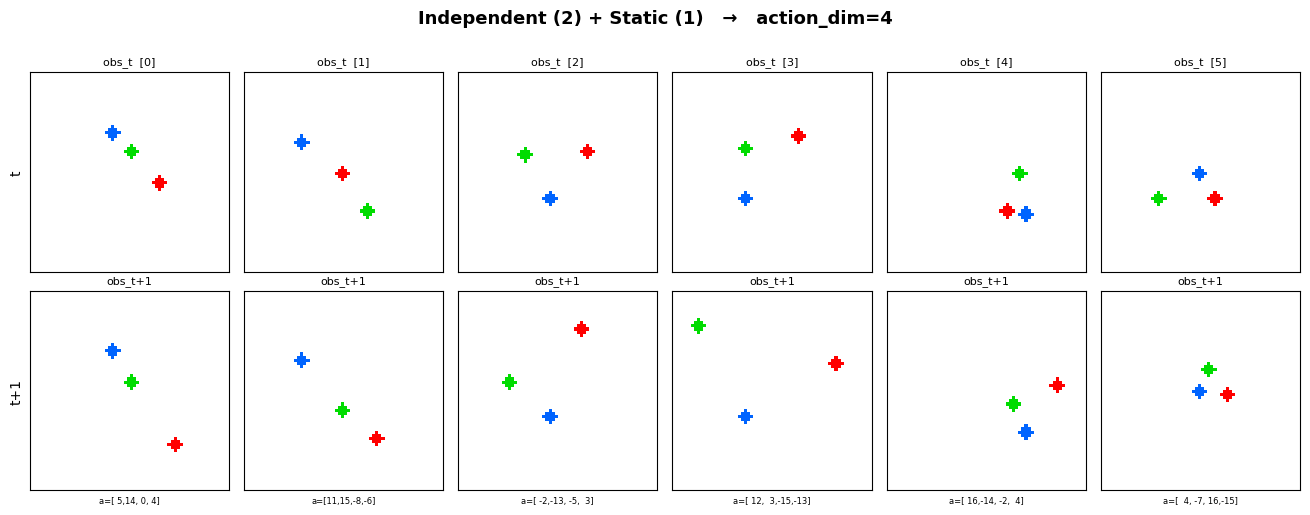

StructuredDotWorldConfig  |  64×64 px  |  radius=2  |  action_dim=4
  group 0: 2 dots  motion=INDEPENDENT  action_dim=4  max_disp=16
  group 1: 1 dots  motion=STATIC  action_dim=0  max_disp=1 



In [3]:
cfg_ind_static = make_independent_static_config(
    num_independent=2,
    num_static=1,
)
ds_ind_static = StructuredDotWorldDataset(config=cfg_ind_static, num_samples=100)
plot_transitions(ds_ind_static, title='Independent (2) + Static (1)   →   action_dim=4')

## 2 — Independent + Random noise

2 controlled dots + 1 randomly moving dot.  
**action_dim = 4** — the random dot moves unpredictably and should ideally be ignored by the encoder.

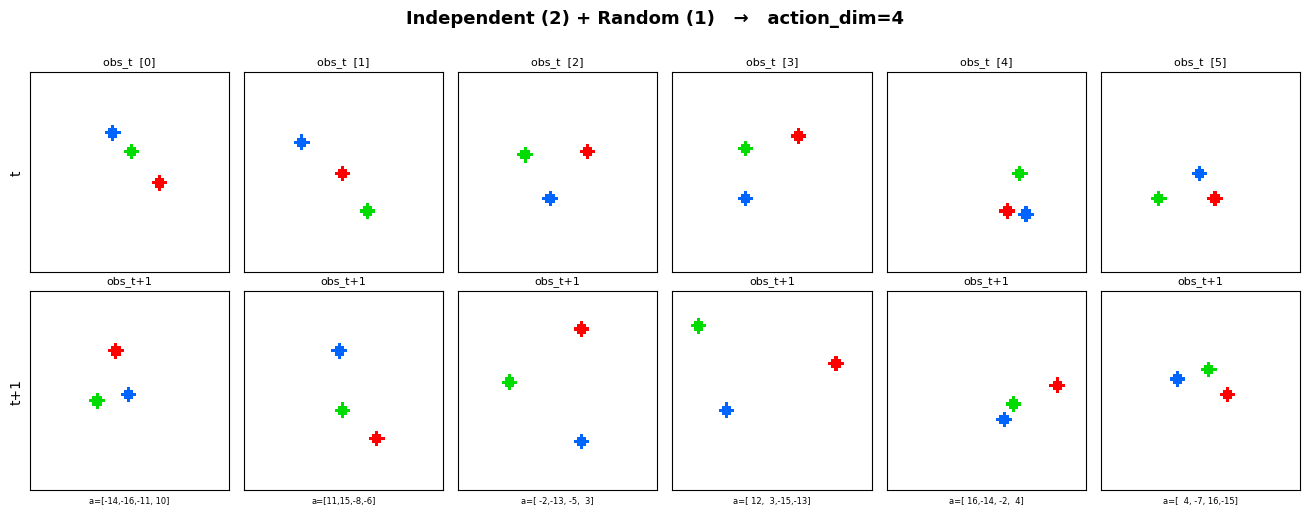

StructuredDotWorldConfig  |  64×64 px  |  radius=2  |  action_dim=4
  group 0: 2 dots  motion=INDEPENDENT  action_dim=4  max_disp=16
  group 1: 1 dots  motion=RANDOM  action_dim=0  max_disp=16 



In [4]:
cfg_ind_rand = make_independent_random_config(
    num_independent=2,
    num_random=1,
)
ds_ind_rand = StructuredDotWorldDataset(config=cfg_ind_rand, num_samples=100)
plot_transitions(ds_ind_rand, title='Independent (2) + Random (1)   →   action_dim=4')

## 3 — Coupled pairs

2 coupled pairs (4 dots total).  Each pair of dots moves rigidly together.  
**action_dim = 4** even though there are 4 dots — effective dimensionality is the same as 2 independent dots.

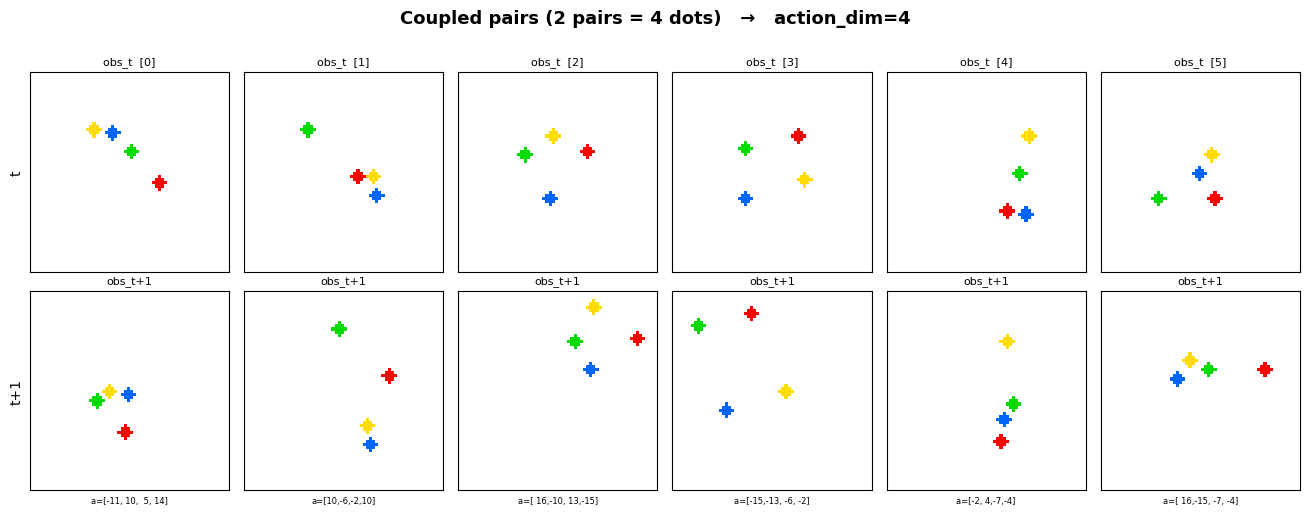

StructuredDotWorldConfig  |  64×64 px  |  radius=2  |  action_dim=4
  group 0: 4 dots  motion=COUPLED  action_dim=4  max_disp=16 



In [5]:
cfg_coupled = make_coupled_config(num_pairs=2)
ds_coupled = StructuredDotWorldDataset(config=cfg_coupled, num_samples=100)
plot_transitions(ds_coupled, title='Coupled pairs (2 pairs = 4 dots)   →   action_dim=4')

## 4 — Combined: Independent + Coupled + Random

1 independent dot + 1 coupled pair (2 dots) + 1 random dot = **4 dots total**.  
**action_dim = 4** (1 independent × 2 + 1 pair × 2)

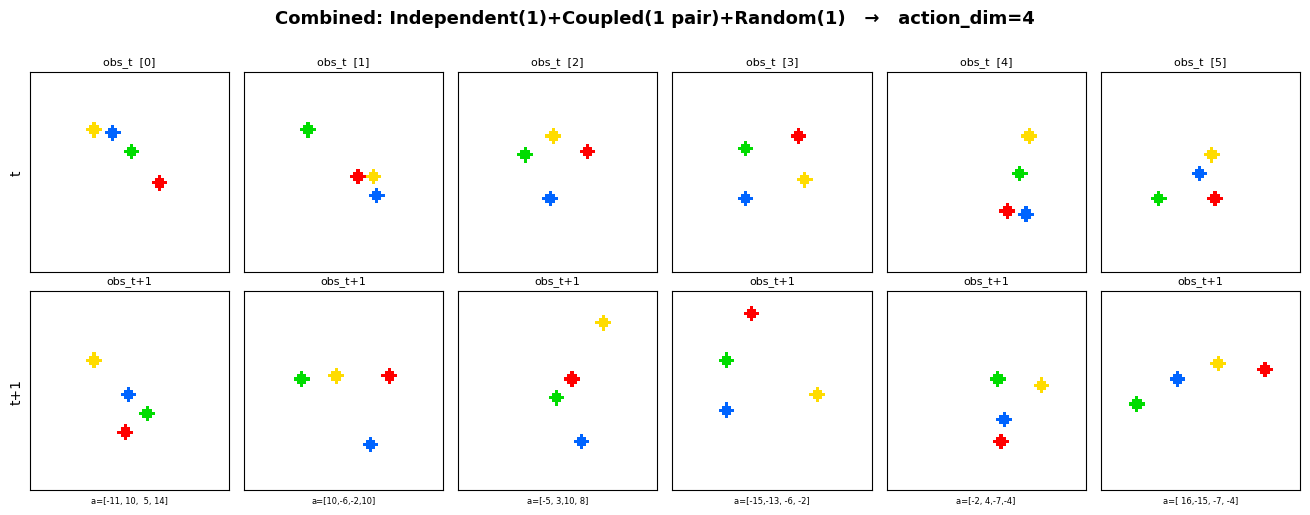

StructuredDotWorldConfig  |  64×64 px  |  radius=2  |  action_dim=4
  group 0: 1 dots  motion=INDEPENDENT  action_dim=2  max_disp=16
  group 1: 2 dots  motion=COUPLED  action_dim=2  max_disp=16
  group 2: 1 dots  motion=RANDOM  action_dim=0  max_disp=16 



In [6]:
cfg_combined = make_combined_config(
    num_independent=1,
    num_coupled_pairs=1,
    num_random=1,
)
ds_combined = StructuredDotWorldDataset(config=cfg_combined, num_samples=100)
plot_transitions(ds_combined, title='Combined: Independent(1)+Coupled(1 pair)+Random(1)   →   action_dim=4')

## 5 — Action dimension summary across configs

In [7]:
configs = {
    '1 independent dot': make_independent_static_config(1, 0),
    '2 independent dots': make_independent_static_config(2, 0),
    '2 indep + 1 static': make_independent_static_config(2, 1),
    '2 indep + 1 random': make_independent_random_config(2, 1),
    '1 coupled pair (2 dots)': make_coupled_config(1),
    '2 coupled pairs (4 dots)': make_coupled_config(2),
    'combined (1+1pair+1random)': make_combined_config(1, 1, 1),
    'combined (2+2pairs+2random)': make_combined_config(2, 2, 2),
}

print(f'{"Config":<35}  {"num_dots":>8}  {"action_dim":>10}')
print('-' * 60)
for name, cfg in configs.items():
    print(f'{name:<35}  {cfg.num_dots:>8}  {cfg.action_dim:>10}')

Config                               num_dots  action_dim
------------------------------------------------------------
1 independent dot                           1           2
2 independent dots                          2           4
2 indep + 1 static                          3           4
2 indep + 1 random                          3           4
1 coupled pair (2 dots)                     2           2
2 coupled pairs (4 dots)                    4           4
combined (1+1pair+1random)                  4           4
combined (2+2pairs+2random)                 8           8


## 6 — Trajectory rollout (coupled pair)

Visualise how a coupled pair moves across multiple steps to verify that both dots in a pair always receive the same displacement.

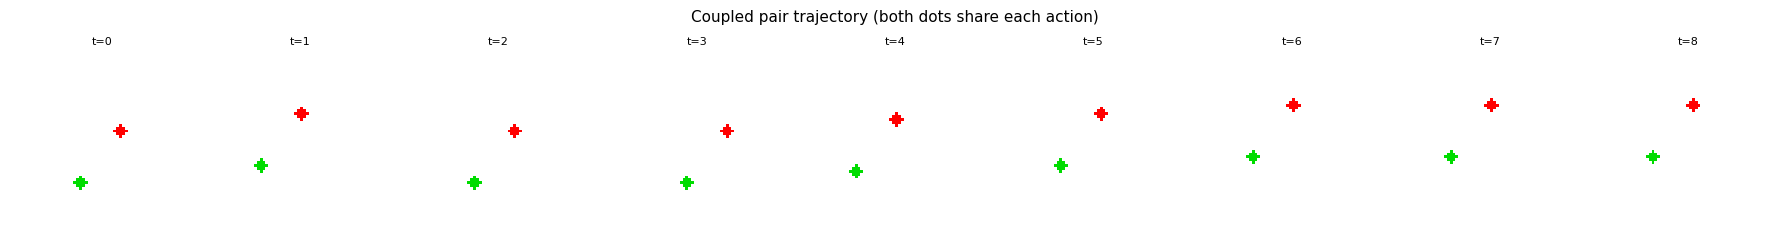

Positions per step (dot0_x, dot0_y, dot1_x, dot1_y):
  t=0: [38 27 24 45]
  t=1: [32 21 18 39]
  t=2: [37 27 23 45]
  t=3: [42 27 28 45]
  t=4: [32 23 18 41]
  t=5: [34 21 20 39]
  t=6: [32 18 18 36]
  t=7: [32 18 18 36]
  t=8: [33 18 19 36]

Actions applied (dx, dy shared by both dots):
  t=0→1: [-6 -6]
  t=1→2: [5 6]
  t=2→3: [5 0]
  t=3→4: [-10  -4]
  t=4→5: [ 2 -2]
  t=5→6: [-2 -3]
  t=6→7: [0 0]
  t=7→8: [1 0]


In [8]:
cfg_traj = make_coupled_config(num_pairs=1)
obs, actions, positions = generate_trajectory(cfg_traj, num_steps=8, seed=8)

T = obs.shape[0]
fig, axes = plt.subplots(1, T, figsize=(2 * T, 2.5))
fig.suptitle('Coupled pair trajectory (both dots share each action)', fontsize=11)

for t in range(T):
    axes[t].imshow(obs[t].transpose(1, 2, 0), interpolation='nearest')
    axes[t].set_title(f't={t}', fontsize=8)
    axes[t].axis('off')

plt.tight_layout()
plt.show()

print('Positions per step (dot0_x, dot0_y, dot1_x, dot1_y):')
for t, p in enumerate(positions):
    print(f'  t={t}: {p.flatten()}')

print('\nActions applied (dx, dy shared by both dots):')
for t, a in enumerate(actions):
    print(f'  t={t}→{t+1}: {a.astype(int)}')

## 7 — Random noise: verify action does not include random dot

The action vector has `action_dim=2` (1 controlled dot).  The random dot moves but is not recorded in the action.

In [9]:
cfg_noise = make_independent_random_config(num_independent=1, num_random=1)
ds_noise = StructuredDotWorldDataset(config=cfg_noise, num_samples=50)

print(f'action_dim = {cfg_noise.action_dim}  (only the 1 controlled dot)')
for i in range(5):
    obs_t, action, obs_tp1, pos_t = ds_noise[i]
    print(f'  sample {i}:  action = {action.numpy().astype(int)}')

action_dim = 2  (only the 1 controlled dot)
  sample 0:  action = [ -6 -15]
  sample 1:  action = [-15 -12]
  sample 2:  action = [-3 10]
  sample 3:  action = [-11  10]
  sample 4:  action = [15 16]


## 8 — DataLoader compatibility check

In [10]:
loader = DataLoader(ds_combined, batch_size=32, shuffle=True, num_workers=0)
obs_t_batch, action_batch, obs_tp1_batch, pos_batch = next(iter(loader))

print('obs_t    :', obs_t_batch.shape,   obs_t_batch.dtype)
print('action   :', action_batch.shape,  action_batch.dtype)
print('obs_tp1  :', obs_tp1_batch.shape, obs_tp1_batch.dtype)
print('pos_t    :', pos_batch.shape,     pos_batch.dtype)

obs_t    : torch.Size([32, 3, 64, 64]) torch.float32
action   : torch.Size([32, 4]) torch.float32
obs_tp1  : torch.Size([32, 3, 64, 64]) torch.float32
pos_t    : torch.Size([32, 8]) torch.float32
